In [13]:
import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import random
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy.stats import entropy
warnings.filterwarnings('ignore')

# --- Reproducibility & Global Parameters ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Assignment Parameters
N_PREV = 10  # Input sequence length (30 beats)
M_OUT = 20   # Output prediction length (20 beats)
BEAT_LENGTH = 3750 # Length of one PPG beat array (assumed from previous output)

# Paths & output dir (fixed to be Path objects)
INPUT_BASE = Path('/kaggle/input/mimi3upload')
PPG_DIR = INPUT_BASE / 'ppg'
ABP_DIR = INPUT_BASE / 'abp'
TRAIN_SUBJ_FILE = INPUT_BASE / 'train_subjects.txt'
VAL_SUBJ_FILE = INPUT_BASE / 'val_subjects.txt'
TEST_SUBJ_FILE = INPUT_BASE / 'test_subjects.txt'

OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Utilities: read subject lists (FIXED TO PARSE LIST STRING) ---
def load_subject_list(path):
    path = Path(path)
    if not path.exists():
        return []
    with open(path, 'r') as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    if len(lines) == 1 and lines[0].strip().startswith("['") and lines[0].strip().endswith("']"):
        try:
            content = lines[0].strip().replace("'", '"')
            return json.loads(content)
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON list in file {path.name}. Returning single line.")
            return lines
    return lines

# Load subject lists
train_subjects = load_subject_list(TRAIN_SUBJ_FILE)
val_subjects = load_subject_list(VAL_SUBJ_FILE)
test_subjects = load_subject_list(TEST_SUBJ_FILE)

print(f"Subjects loaded. Train/Val/Test counts: {len(train_subjects)}, {len(val_subjects)}, {len(test_subjects)}")

Subjects loaded. Train/Val/Test counts: 1100, 195, 229


In [14]:
# --- Map Files to Subjects ---
ppg_files = list(glob.glob(str(PPG_DIR / '*.npy'))) + list(glob.glob(str(PPG_DIR / '*.npz')))
abp_files = list(glob.glob(str(ABP_DIR / '*.npy'))) + list(glob.glob(str(ABP_DIR / '*.npz'))) + list(glob.glob(str(ABP_DIR / '*.csv')))

def create_subject_map(file_list):
    file_map = {}
    for f in file_list:
        p = Path(f).name
        subj_id = p.split('_')[0]
        file_map.setdefault(subj_id, []).append(f)
    return file_map

ppg_map = create_subject_map(ppg_files)
abp_map = create_subject_map(abp_files)

# --- Robust Subject Loader (from your code) ---
def load_subject(ppg_map, abp_map, subject):
    ppg_paths = ppg_map.get(subject, [])
    if len(ppg_paths) == 0: return None
    ppg_list = []
    for p in ppg_paths:
        try:
            arr = np.load(p, allow_pickle=True)
            if isinstance(arr, np.lib.npyio.NpzFile):
                arr = arr[list(arr.keys())[0]]
            ppg_list.append(arr)
        except Exception as e:
            print(f"PPG load error {p}: {e}")
    ppg = np.concatenate([a.reshape((-1, a.shape[-1])) if a.ndim==3 else a for a in ppg_list], axis=0)

    # ABP
    abp_paths = abp_map.get(subject, [])
    abp_arr = None
    for p in abp_paths:
        try:
            if p.endswith('.csv'):
                df = pd.read_csv(p)
                if 'SBP' in df.columns and 'DBP' in df.columns:
                    sbp = df['SBP'].values; dbp = df['DBP'].values
                    abp_arr = np.vstack([sbp, dbp]).T; break
                else: continue
            else:
                arr = np.load(p, allow_pickle=True)
                if isinstance(arr, np.lib.npyio.NpzFile):
                    arr = arr[list(arr.keys())[0]]
                if arr.ndim == 2 and arr.shape[0] == ppg.shape[0]:
                    # Extract SBP/DBP if ABP waveform is present (using max/min)
                    sbp = arr.max(axis=1); dbp = arr.min(axis=1)
                    abp_arr = np.vstack([sbp, dbp]).T; break
                if arr.ndim==2 and arr.shape[1]==2 and arr.shape[0] == ppg.shape[0]:
                    # Already SBP/DBP pairs
                    abp_arr = arr; break
        except Exception as e:
            print(f"ABP load err {p}: {e}")
    
    # Ensure PPG and ABP match in length
    if abp_arr is not None:
        n = min(len(ppg), abp_arr.shape[0])
        return ppg[:n], abp_arr[:n]
    
    return ppg, None

print(f"Found {len(ppg_files)} PPG files and {len(abp_files)} ABP files.")

Found 1524 PPG files and 1524 ABP files.


In [15]:
# --- Combine all subjects into full arrays ---
ppg_all = []
abp_all = []
all_subjects_idx = []

for subj in ppg_map.keys():
    res = load_subject(ppg_map, abp_map, subj)
    if res is None or res[1] is None:
        continue
    
    ppg_beats, abp_labels = res
    n = len(ppg_beats)
    
    # Check for the critical data length issue:
    if n < N_PREV + M_OUT:
        # Skip subjects that are too short to form a single sequence
        # This will be most subjects unless the input data is fixed!
        print(f"Skipping subject {subj}: only {n} beats, need {N_PREV + M_OUT}.")
        continue

    ppg_all.append(ppg_beats)
    abp_all.append(abp_labels)
    all_subjects_idx.extend([subj] * n)

# Stack all arrays
ppg_all = np.vstack(ppg_all)
abp_all = np.vstack(abp_all)
all_subjects_idx = np.array(all_subjects_idx)

print(f"Total beats loaded (passing length check): {ppg_all.shape[0]}")
print(f"Unique subjects loaded: {len(np.unique(all_subjects_idx))}")

Total beats loaded (passing length check): 45720
Unique subjects loaded: 1524


In [16]:
# --- Signal Quality Index (SQI) ---
def ppg_sqi_safe(beat, min_amp=0.02, min_std=1e-4, min_entropy=0.8, flat_thresh=0.95):
    # Filter based on common noise indicators
    if np.isnan(beat).any() or np.isinf(beat).any(): return False
    amp = float(beat.max() - beat.min()) 
    if amp < min_amp: return False
    std = float(beat.std())
    if std < min_std: return False
    
    # Entropy check for signal complexity
    hist, _ = np.histogram(beat, bins=30, density=True)
    hist = hist + 1e-8
    ent = entropy(hist)
    if ent < min_entropy: return False
    
    # Flat segment check
    diffs = np.abs(np.diff(beat))
    if len(diffs)==0: return False
    prop_flat = np.mean(diffs < (1e-6 + 1e-3*std))
    if prop_flat > flat_thresh: return False
    return True

# --- Per-Beat Normalization ---
def normalize_beats(beats):
    # Z-score normalization applied to each beat independently
    means = beats.mean(axis=1, keepdims=True)
    stds = beats.std(axis=1, keepdims=True) + 1e-8
    return (beats - means) / stds

# --- Apply SQI to all data ---
print("Applying full SQI...")
mask = np.array([ppg_sqi_safe(b) for b in ppg_all])
print(f"Full SQI acceptance: {mask.sum()} / {len(mask)} ({100*mask.sum()/len(mask):.2f}%)")

if mask.sum() == 0:
    raise RuntimeError("SQI rejected all beats. Relax thresholds or fix data.")

ppg_clean = ppg_all[mask]
abp_clean = abp_all[mask]
subj_clean = all_subjects_idx[mask]

# Apply per-beat normalization to the cleaned PPG data
ppg_norm = normalize_beats(ppg_clean)

print(f"Cleaned and Normalized PPG shape: {ppg_norm.shape}")

Applying full SQI...
Full SQI acceptance: 45720 / 45720 (100.00%)
Cleaned and Normalized PPG shape: (45720, 3750)


In [17]:
# --- Sequence Creator Utility ---
def create_sequences(ppg_beats, abp_labels, N_prev=N_PREV, M_out=M_OUT, stride=1):
    T = ppg_beats.shape[0]
    # T must be at least N_prev + M_out (which is 30 in our adjusted case)
    if T < N_prev + M_out:
        return np.zeros((0, N_prev, ppg_beats.shape[1])), np.zeros((0, M_out, 2))
    
    X_idx = []
    y = []
    
    # Since T = N_prev + M_out = 30, this loop runs only for start=0
    for start in range(0, T - N_prev - M_out + 1, stride):
        # Input: N_prev beats (from start to start + N_prev)
        X_idx.append((start, start + N_prev))
        # Output: M_out labels (from start + N_prev to start + N_prev + M_out)
        y.append(abp_labels[start + N_prev : start + N_prev + M_out])
        
    X = np.stack([ppg_beats[s:e] for (s,e) in X_idx], axis=0)
    y = np.stack(y, axis=0)
    return X, y

# --- Subject-Wise Sequence Generation ---
all_X = []
all_y = []
all_seq_subj_idx = []

unique_subjects = np.unique(subj_clean) 

print("Creating sequences subject-by-subject...")
for subj in unique_subjects:
    subj_mask = (subj_clean == subj)
    subj_ppg_norm = ppg_norm[subj_mask]
    subj_abp_clean = abp_clean[subj_mask]
    
    # We must account for subjects whose beats were filtered by SQI
    if len(subj_ppg_norm) < N_PREV + M_OUT:
        print(f"Skipping subject {subj} after SQI: only {len(subj_ppg_norm)} beats, need {N_PREV + M_OUT}.")
        continue

    X_subj, y_subj = create_sequences(subj_ppg_norm, subj_abp_clean, 
                                      N_prev=N_PREV, M_out=M_OUT, stride=1)
    
    if X_subj.shape[0] > 0:
        all_X.append(X_subj)
        all_y.append(y_subj)
        all_seq_subj_idx.extend([subj] * X_subj.shape[0])

X_final = np.concatenate(all_X, axis=0)
y_final = np.concatenate(all_y, axis=0)
all_seq_subj_idx = np.array(all_seq_subj_idx)

print(f"Final Sequences created: X shape {X_final.shape}, y shape {y_final.shape}")

Creating sequences subject-by-subject...
Final Sequences created: X shape (1524, 10, 3750), y shape (1524, 20, 2)


In [18]:
# --- Sequence-Level Subject Splitting ---
train_mask = np.isin(all_seq_subj_idx, train_subjects)
val_mask = np.isin(all_seq_subj_idx, val_subjects)
test_mask = np.isin(all_seq_subj_idx, test_subjects)

X_train, y_train = X_final[train_mask], y_final[train_mask]
X_val, y_val = X_final[val_mask], y_final[val_mask]
X_test, y_test = X_final[test_mask], y_final[test_mask]

print(f"Train sequences: {X_train.shape[0]}, Val sequences: {X_val.shape[0]}, Test sequences: {X_test.shape[0]}")

# --- PyTorch Dataset and DataLoader ---
class PPGSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_dataset = PPGSequenceDataset(X_train, y_train)
val_dataset = PPGSequenceDataset(X_val, y_val)
test_dataset = PPGSequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train sequences: 1100, Val sequences: 195, Test sequences: 229


In [19]:
# --- Calculate BP Normalization Constants from Training Data (in mmHg) ---

# y_train shape is (N_seq, M_OUT, 2). Reshape to (N_all_beats, 2)
y_train_flat = y_train.reshape(-1, 2)

# Calculate Mean and Std Dev for SBP (col 0) and DBP (col 1)
BP_MEAN = y_train_flat.mean(axis=0)
BP_STD = y_train_flat.std(axis=0) + 1e-8 # Add epsilon for stability

# --- Apply Normalization to all target sets ---
def apply_bp_normalization(y_data, mean, std):
    # y_data shape: (N_seq, M_OUT, 2)
    return (y_data - mean) / std

y_train_norm = apply_bp_normalization(y_train, BP_MEAN, BP_STD)
y_val_norm = apply_bp_normalization(y_val, BP_MEAN, BP_STD)
y_test_norm = apply_bp_normalization(y_test, BP_MEAN, BP_STD)

print("--- BP Target Normalization Applied ---")
print(f"BP_MEAN (mmHg): {BP_MEAN}")
print(f"BP_STD (mmHg): {BP_STD}")
print(f"y_train_norm mean/std check (should be near 0/1): {y_train_norm.mean(axis=(0,1)).round(3)}, {y_train_norm.std(axis=(0,1)).round(3)}")

# --- Re-initialize PyTorch Datasets with Normalized Targets ---
train_dataset = PPGSequenceDataset(X_train, y_train_norm)
val_dataset = PPGSequenceDataset(X_val, y_val_norm)
test_dataset = PPGSequenceDataset(X_test, y_test_norm)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

--- BP Target Normalization Applied ---
BP_MEAN (mmHg): [117.45443511  55.50184828]
BP_STD (mmHg): [18.32621783 12.1029586 ]
y_train_norm mean/std check (should be near 0/1): [0. 0.], [1. 1.]


In [38]:
import torch
import torch.nn as nn

# Example hyperparams (keep consistent)
INPUT_DIM = BEAT_LENGTH   # e.g. 128
HIDDEN_DIM = 128
ENCODER_LAYERS = 2        # number of LSTM layers in encoder
DECODER_LAYERS = 2        # must match encoder if you want to pass states directly
DROPOUT_RATE = 0.2
M_OUT = 20
N_PREV = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class BiLSTM_Seq2Seq(nn.Module):
    """
    Bidirectional LSTM encoder -> Unidirectional LSTM decoder seq2seq.
    Encoder is bidirectional; decoder hidden size = encoder_hidden_dim * 2.
    encoder_layers and decoder_layers should match for direct hidden-state transfer.
    """
    def __init__(self,
                 input_dim,
                 enc_hidden_dim,
                 encoder_layers=1,
                 decoder_layers=None,
                 dropout_rate=0.0,
                 M_out=20,
                 n_prev=20,
                 device=DEVICE):
        super().__init__()
        self.device = device
        self.input_dim = input_dim
        self.enc_hidden_dim = enc_hidden_dim
        self.encoder_layers = encoder_layers
        # If decoder_layers not provided, default to same as encoder_layers
        self.decoder_layers = decoder_layers if decoder_layers is not None else encoder_layers
        self.num_directions = 2  # because encoder is bidirectional
        self.M_out = M_out

        # Encoder: bidirectional LSTM
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=enc_hidden_dim,
            num_layers=self.encoder_layers,
            batch_first=False,
            bidirectional=True,
            dropout=dropout_rate if self.encoder_layers > 1 else 0.0
        )

        # Decoder hidden size must be enc_hidden_dim * num_directions
        dec_hidden_dim = enc_hidden_dim * self.num_directions

        # Decoder: unidirectional LSTM
        self.decoder = nn.LSTM(
            input_size=2,                 # we feed previous (SBP, DBP) as input
            hidden_size=dec_hidden_dim,
            num_layers=self.decoder_layers,
            batch_first=False,
            bidirectional=False,
            dropout=dropout_rate if self.decoder_layers > 1 else 0.0
        )

        # Final output projection: decode hidden -> 2 values (SBP, DBP)
        self.output_layer = nn.Linear(dec_hidden_dim, 2)

    def _merge_bi_states(self, hid):
        """
        Merge bidirectional encoder states into decoder initial states.

        hid: tensor of shape (num_layers * num_directions, B, H)
        returns: tensor of shape (num_layers, B, H * num_directions)
        """
        # sanity checks
        expected_rows = self.encoder_layers * self.num_directions
        if hid.size(0) != expected_rows:
            raise RuntimeError(
                f"Encoder state first dim ({hid.size(0)}) != expected ({expected_rows}). "
                "Check encoder_layers/num_directions."
            )

        # For each encoder layer l, concatenate forward (2*l) and backward (2*l+1)
        merged = []
        for l in range(self.encoder_layers):
            forward = hid[2 * l]        # shape: (B, H)
            backward = hid[2 * l + 1]   # shape: (B, H)
            merged_l = torch.cat([forward, backward], dim=1)  # (B, H*2)
            merged.append(merged_l.unsqueeze(0))             # (1, B, H*2)
        # stacked -> (encoder_layers, B, H*2)
        return torch.cat(merged, dim=0)

    def forward(self, X):
        """
        X: (B, N_PREV, input_dim)  -> permute to (N_PREV, B, input_dim)
        returns: (B, M_out, 2)
        """
        batch_size = X.shape[0]
        X_seq = X.permute(1, 0, 2).contiguous()  # (N_PREV, B, input_dim)

        encoder_outputs, (encoder_h, encoder_c) = self.encoder(X_seq)
        # encoder_h shape: (encoder_layers * 2, B, enc_hidden_dim)

        # Merge forward/backward per layer -> (encoder_layers, B, enc_hidden_dim*2)
        merged_h = self._merge_bi_states(encoder_h)     # (enc_layers, B, H*2)
        merged_c = self._merge_bi_states(encoder_c)     # same for cell

        # If decoder_layers != encoder_layers, raise (safer). If you want to support repeating,
        # implement explicit broadcasting logic here — but be explicit about it.
        if self.decoder_layers != self.encoder_layers:
            raise RuntimeError(
                f"Decoder layers ({self.decoder_layers}) != Encoder layers ({self.encoder_layers}). "
                "Please initialize encoder/decoder with the same number of layers, or modify "
                "the model to specify how to map encoder states to decoder states."
            )

        # Set initial decoder hidden/cell as the merged encoder states
        decoder_hidden = merged_h.contiguous()  # (decoder_layers, B, dec_hidden_dim)
        decoder_cell = merged_c.contiguous()

        # Prepare first decoder input: zeros (B, 2)
        decoder_input = torch.zeros(batch_size, 2, device=self.device)

        outputs = []
        for t in range(self.M_out):
            # decoder expects input shape (seq_len=1, batch, input_size)
            dec_in = decoder_input.unsqueeze(0)  # (1, B, 2)
            decoder_output, (decoder_hidden, decoder_cell) = self.decoder(
                dec_in, (decoder_hidden, decoder_cell)
            )
            # decoder_output: (1, B, dec_hidden_dim) -> squeeze -> (B, dec_hidden_dim)
            out_t = self.output_layer(decoder_output.squeeze(0))
            outputs.append(out_t)
            # autoregressive next input (detach to avoid backprop through predictions)
            decoder_input = out_t.detach()

        # stack -> (M_out, B, 2) -> permute -> (B, M_out, 2)
        outputs = torch.stack(outputs, dim=0).permute(1, 0, 2).contiguous()
        return outputs


# -------------------
# Example initialization (make encoder/decoder layers explicit & matching)
# -------------------
model_bilstm = BiLSTM_Seq2Seq(
    input_dim=INPUT_DIM,
    enc_hidden_dim=HIDDEN_DIM,
    encoder_layers=ENCODER_LAYERS,
    decoder_layers=DECODER_LAYERS,
    dropout_rate=DROPOUT_RATE,
    M_out=M_OUT,
    n_prev=N_PREV,
    device=DEVICE
).to(DEVICE)

total_params = sum(p.numel() for p in model_bilstm.parameters() if p.requires_grad)
print(f"Model 1 (BiLSTM) initialized. Total trainable parameters: {total_params}")


Model 1 (BiLSTM) initialized. Total parameters: 5161474


In [40]:
# ===============================
#  FIXED ADDITIVE ATTENTION
# ===============================
class AdditiveAttention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()

        # Combined size = H_enc(2H) + H_dec(H_dec)
        self.attn = nn.Linear(enc_hidden_dim + dec_hidden_dim, dec_hidden_dim)
        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden_last):
        # encoder_outputs: (N_PREV, B, 2H)
        # decoder_hidden_last: (B, H_dec)

        seq_len, batch_size, enc_dim = encoder_outputs.shape
        dec_dim = decoder_hidden_last.size(-1)

        # Expand decoder hidden (N_PREV, B, H_dec)
        dec_hidden_expanded = decoder_hidden_last.unsqueeze(0).repeat(seq_len, 1, 1)

        # Concatenate (N_PREV, B, 2H + H_dec)
        combined = torch.cat((encoder_outputs, dec_hidden_expanded), dim=2)

        # Energy → softmax across seq_len
        energy = self.v(torch.tanh(self.attn(combined))).squeeze(2)
        attn_scores = F.softmax(energy, dim=0)

        # Weighted sum → context (B, 2H)
        context = (encoder_outputs * attn_scores.unsqueeze(2)).sum(dim=0)

        return context, attn_scores


# ===============================
# FIXED ATTENTION SEQ2SEQ MODEL
# Encoder: BiLSTM (num_layers)
# Decoder: UniLSTM (num_layers)
# Layer mapping: Perfectly aligned
# ===============================
class Attention_Seq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout_rate, M_out, n_prev):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.M_out = M_out

        # ------------------------------
        # 1. Encoder: BiLSTM
        # ------------------------------
        self.encoder = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            dropout=dropout_rate, batch_first=False, bidirectional=True
        )

        # ------------------------------
        # 2. Decoder: Uni-directional LSTM
        # Hidden size = 2*H to match BiLSTM output
        # ------------------------------
        self.decoder = nn.LSTM(
            input_size=hidden_dim*2 + 2,   # Context + previous output
            hidden_size=hidden_dim*2,
            num_layers=num_layers,
            dropout=dropout_rate,
            batch_first=False,
            bidirectional=False
        )

        # ------------------------------
        # 3. Attention
        # ------------------------------
        self.attention = AdditiveAttention(
            enc_hidden_dim=hidden_dim*2,    # BiLSTM output
            dec_hidden_dim=hidden_dim*2     # Decoder hidden size
        )

        # ------------------------------
        # 4. Output Linear Layer
        # ------------------------------
        self.output_layer = nn.Linear(hidden_dim*2, 2)


    # ====================================================
    #      FORWARD PASS
    # ====================================================
    def forward(self, X):
        batch_size = X.size(0)

        # Input shape: (B, N_prev, D) → (N_prev, B, D)
        X = X.permute(1, 0, 2)

        # --------------------------------------
        # ENCODER
        # --------------------------------------
        encoder_outputs, (h_enc, c_enc) = self.encoder(X)
        # h_enc: (2*num_layers, B, H)
        # c_enc: same

        # -------------------------------------------------
        # FIXED: Proper mapping BiLSTM → Decoder layers
        # -------------------------------------------------
        # Merge forward/backward for each layer:
        # h_enc[0], h_enc[1] -> layer 0
        # h_enc[2], h_enc[3] -> layer 1 ...
        h_dec = []
        c_dec = []
        for i in range(self.num_layers):
            h_f = h_enc[2*i]
            h_b = h_enc[2*i + 1]
            c_f = c_enc[2*i]
            c_b = c_enc[2*i + 1]

            h_dec.append(torch.cat((h_f, h_b), dim=1))  # (B, 2H)
            c_dec.append(torch.cat((c_f, c_b), dim=1))

        # Stack to match decoder LSTM format:
        # (num_layers, B, 2H)
        h_dec = torch.stack(h_dec, dim=0)
        c_dec = torch.stack(c_dec, dim=0)

        # --------------------------------------
        # DECODER LOOP
        # --------------------------------------
        decoder_hidden = (h_dec, c_dec)
        decoder_input = torch.zeros(batch_size, 2, device=X.device)  # initial SBP/DBP

        outputs = []
        attn_list = []

        for t in range(self.M_out):

            # Get top layer hidden (B, 2H)
            last_dec_hidden = decoder_hidden[0][-1]

            # Attention
            context, attn_scores = self.attention(encoder_outputs, last_dec_hidden)
            attn_list.append(attn_scores)

            # Decoder input concat
            inp = torch.cat((context, decoder_input), dim=1).unsqueeze(0)

            # LSTM step
            dec_out, decoder_hidden = self.decoder(inp, decoder_hidden)

            # Predict SBP/DBP
            out_t = self.output_layer(dec_out.squeeze(0))
            outputs.append(out_t)

            decoder_input = out_t.detach()

        outputs = torch.stack(outputs, dim=1)
        attn_list = torch.stack(attn_list, dim=0)

        return outputs, attn_list

In [41]:
# --- Denormalization Function (uses global BP_MEAN/BP_STD) ---
def denormalize(data):
    # data is a tensor (N, M_OUT, 2)
    # BP_MEAN/BP_STD must be converted to tensors and moved to device if necessary, 
    # but using .cpu() conversion later is safer.
    return data * torch.from_numpy(BP_STD).float() + torch.from_numpy(BP_MEAN).float()

# --- Metrics (Updated to Denormalize) ---
def calculate_metrics(y_true_norm, y_pred_norm):
    # Denormalize predictions and targets before calculating metrics in mmHg
    y_true = denormalize(y_true_norm).cpu().numpy().reshape(-1, 2)
    y_pred = denormalize(y_pred_norm).cpu().numpy().reshape(-1, 2)
    
    # Separate SBP (column 0) and DBP (column 1)
    mae_sbp = np.mean(np.abs(y_pred[:, 0] - y_true[:, 0]))
    mae_dbp = np.mean(np.abs(y_pred[:, 1] - y_true[:, 1]))
    
    # Overall Metrics (combining SBP and DBP)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))
    
    # R2 Score (Coefficient of Determination)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / (ss_tot + 1e-8))
    
    return mae, rmse, r2, mae_sbp, mae_dbp

@torch.no_grad()
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        y_pred_output = model(X_batch)
        y_pred = y_pred_output[0] if isinstance(y_pred_output, tuple) else y_pred_output
        
        loss = criterion(y_pred, y_batch)
        total_loss += loss.item()
        
        all_preds.append(y_pred.cpu())
        all_targets.append(y_batch.cpu())
        
    avg_loss = total_loss / len(dataloader)
    
    # Concatenate normalized predictions and targets
    all_preds_norm = torch.cat(all_preds, dim=0)
    all_targets_norm = torch.cat(all_targets, dim=0)
    
    # Calculate full metrics using the denormalized values
    mae, rmse, r2, mae_sbp, mae_dbp = calculate_metrics(all_targets_norm, all_preds_norm)
    
    # Denormalize the full prediction/target arrays for plotting/horizon calculation
    all_preds_denorm = denormalize(all_preds_norm).numpy()
    all_targets_denorm = denormalize(all_targets_norm).numpy()
    
    return avg_loss, mae, rmse, r2, mae_sbp, mae_dbp, all_preds_denorm, all_targets_denorm

def train_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        y_pred_output = model(X_batch) 
        y_pred = y_pred_output[0] if isinstance(y_pred_output, tuple) else y_pred_output
        
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

def calculate_horizon_error(y_true, y_pred):
    # This function receives already denormalized data
    abs_error = np.abs(y_pred - y_true)
    mae_horizon = np.mean(abs_error, axis=0)
    squared_error = (y_pred - y_true)**2
    rmse_horizon = np.sqrt(np.mean(squared_error, axis=0))
    return mae_horizon, rmse_horizon

In [24]:
# --- Model Weight Reset ---
# This step resets the weights because the previous training run used incorrect (unnormalized) targets.
# Assuming HIDDEN_DIM, NUM_LAYERS, DROPOUT_RATE, M_OUT, N_PREV, BEAT_LENGTH are defined globally
# And assuming BiLSTM_Seq2Seq and Attention_Seq2Seq classes are defined in previous cells.

# 1. BiLSTM Re-Initialization
# Note: This creates a NEW model instance with fresh, random weights.
model_bilstm = BiLSTM_Seq2Seq(BEAT_LENGTH, HIDDEN_DIM, NUM_LAYERS, DROPOUT_RATE, M_OUT, N_PREV).to(DEVICE)

# 2. Attention Re-Initialization
model_attn = Attention_Seq2Seq(BEAT_LENGTH, HIDDEN_DIM, NUM_LAYERS, DROPOUT_RATE, M_OUT, N_PREV).to(DEVICE)

print("Models successfully re-initialized with fresh weights, ready for training with normalized targets.")

Models successfully re-initialized with fresh weights, ready for training with normalized targets.


In [25]:
# --- Training Loop Setup for Model 1 ---
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
MODEL_NAME = 'bilstm'

criterion = nn.SmoothL1Loss(reduction='mean', beta=1.0) 
optimizer_bilstm = torch.optim.Adam(model_bilstm.parameters(), lr=LEARNING_RATE)
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler_bilstm = ReduceLROnPlateau(optimizer_bilstm, mode='min', factor=0.5, patience=5, verbose=True)

history_bilstm = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss_bilstm = float('inf')
best_epoch_bilstm = 0

# Ensure OUTPUT_DIR is defined (assuming it was defined in a prior setup cell)
from pathlib import Path
OUTPUT_DIR = Path('.') # Placeholder if not defined

print(f"Starting training for Model 1: {MODEL_NAME.upper()}...")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model_bilstm, train_loader, criterion, optimizer_bilstm)
    
    val_loss, val_mae, _, _, _, _, _, _ = evaluate_model(model_bilstm, val_loader, criterion)
    
    scheduler_bilstm.step(val_loss)
    
    history_bilstm['train_loss'].append(train_loss)
    history_bilstm['val_loss'].append(val_loss)
    history_bilstm['val_mae'].append(val_mae)
    
    # Early Stopping Check
    if val_loss < best_val_loss_bilstm:
        best_val_loss_bilstm = val_loss
        best_epoch_bilstm = epoch
        torch.save(model_bilstm.state_dict(), OUTPUT_DIR / f'best_model_{MODEL_NAME}.pth')
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{NUM_EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val MAE={val_mae:.2f} mmHg, LR={optimizer_bilstm.param_groups[0]['lr']:.1e}")

# Load best model for final evaluation
model_bilstm.load_state_dict(torch.load(OUTPUT_DIR / f'best_model_{MODEL_NAME}.pth'))
print(f"\nTraining for {MODEL_NAME.upper()} finished. Loaded best model from epoch {best_epoch_bilstm}.")

# Test Set Evaluation
test_loss_bilstm, test_mae_bilstm, test_rmse_bilstm, test_r2_bilstm, test_mae_sbp_bilstm, test_mae_dbp_bilstm, pred_bilstm, target_bilstm = evaluate_model(model_bilstm, test_loader, criterion)

print("\n" + "="*40)
print(f"FINAL TEST RESULTS: Model 1 ({MODEL_NAME.upper()})")
print(f"Overall Test MAE: {test_mae_bilstm:.3f} mmHg")
print(f"Test SBP MAE: {test_mae_sbp_bilstm:.3f} mmHg")
print(f"Test DBP MAE: {test_mae_dbp_bilstm:.3f} mmHg")
print(f"Test RMSE: {test_rmse_bilstm:.3f} mmHg")
print(f"Test R2 Score: {test_r2_bilstm:.3f}")
print("="*40)

# Store results for final comparison
results = {'BiLSTM': {
    'MAE': test_mae_bilstm, 'RMSE': test_rmse_bilstm, 'R2': test_r2_bilstm,
    'MAE_SBP': test_mae_sbp_bilstm, 'MAE_DBP': test_mae_dbp_bilstm,
    'preds': pred_bilstm, 'targets': target_bilstm
}}


Starting training for Model 1: BILSTM...
Epoch 1/50: Train Loss=0.4116, Val Loss=0.3768, Val MAE=11.69 mmHg, LR=1.0e-04
Epoch 10/50: Train Loss=0.2274, Val Loss=0.3938, Val MAE=12.13 mmHg, LR=5.0e-05
Epoch 20/50: Train Loss=0.1820, Val Loss=0.4041, Val MAE=12.28 mmHg, LR=2.5e-05
Epoch 30/50: Train Loss=0.1763, Val Loss=0.4048, Val MAE=12.29 mmHg, LR=6.3e-06
Epoch 40/50: Train Loss=0.1744, Val Loss=0.4046, Val MAE=12.28 mmHg, LR=1.6e-06
Epoch 50/50: Train Loss=0.1788, Val Loss=0.4048, Val MAE=12.29 mmHg, LR=7.8e-07

Training for BILSTM finished. Loaded best model from epoch 4.

FINAL TEST RESULTS: Model 1 (BILSTM)
Overall Test MAE: 11.834 mmHg
Test SBP MAE: 14.469 mmHg
Test DBP MAE: 9.199 mmHg
Test RMSE: 15.201 mmHg
Test R2 Score: 0.801


In [28]:
# --- Training Loop Setup for Model 2 ---
import torch.nn.functional as F 
MODEL_NAME = 'attention'

optimizer_attn = torch.optim.Adam(model_attn.parameters(), lr=LEARNING_RATE)
scheduler_attn = ReduceLROnPlateau(optimizer_attn, mode='min', factor=0.5, patience=5, verbose=True)

history_attn = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss_attn = float('inf')
best_epoch_attn = 0

print(f"\nStarting training for Model 2: {MODEL_NAME.upper()}...")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model_attn, train_loader, criterion, optimizer_attn)
    
    val_loss, val_mae, _, _, _, _, _, _ = evaluate_model(model_attn, val_loader, criterion)
    
    scheduler_attn.step(val_loss)
    
    history_attn['train_loss'].append(train_loss)
    history_attn['val_loss'].append(val_loss)
    history_attn['val_mae'].append(val_mae)
    
    # Early Stopping Check
    if val_loss < best_val_loss_attn:
        best_val_loss_attn = val_loss
        best_epoch_attn = epoch
        torch.save(model_attn.state_dict(), OUTPUT_DIR / f'best_model_{MODEL_NAME}.pth')
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{NUM_EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val MAE={val_mae:.2f} mmHg, LR={optimizer_attn.param_groups[0]['lr']:.1e}")

# Load best model for final evaluation
model_attn.load_state_dict(torch.load(OUTPUT_DIR / f'best_model_{MODEL_NAME}.pth'))
print(f"\nTraining for {MODEL_NAME.upper()} finished. Loaded best model from epoch {best_epoch_attn}.")

# Test Set Evaluation (Task 9 & 10)
test_loss_attn, test_mae_attn, test_rmse_attn, test_r2_attn, test_mae_sbp_attn, test_mae_dbp_attn, pred_attn, target_attn = evaluate_model(model_attn, test_loader, criterion)

print("\n" + "="*40)
print(f"FINAL TEST RESULTS: Model 2 ({MODEL_NAME.upper()})")
print(f"Overall Test MAE: {test_mae_attn:.3f} mmHg")
print(f"Test SBP MAE: {test_mae_sbp_attn:.3f} mmHg")
print(f"Test DBP MAE: {test_mae_dbp_attn:.3f} mmHg")
print(f"Test RMSE: {test_rmse_attn:.3f} mmHg")
print(f"Test R2 Score: {test_r2_attn:.3f}")
print("="*40)

# Store results for final comparison
results['Attention'] = {
    'MAE': test_mae_attn, 'RMSE': test_rmse_attn, 'R2': test_r2_attn,
    'MAE_SBP': test_mae_sbp_attn, 'MAE_DBP': test_mae_dbp_attn,
    'preds': pred_attn, 'targets': target_attn
}


Starting training for Model 2: ATTENTION...
Epoch 1/50: Train Loss=0.4192, Val Loss=0.3756, Val MAE=11.70 mmHg, LR=1.0e-04
Epoch 10/50: Train Loss=0.2147, Val Loss=0.3871, Val MAE=11.91 mmHg, LR=5.0e-05
Epoch 20/50: Train Loss=0.1747, Val Loss=0.3920, Val MAE=12.03 mmHg, LR=1.3e-05
Epoch 30/50: Train Loss=0.1667, Val Loss=0.3948, Val MAE=12.05 mmHg, LR=6.3e-06
Epoch 40/50: Train Loss=0.1685, Val Loss=0.3959, Val MAE=12.05 mmHg, LR=1.6e-06
Epoch 50/50: Train Loss=0.1660, Val Loss=0.3963, Val MAE=12.05 mmHg, LR=3.9e-07

Training for ATTENTION finished. Loaded best model from epoch 1.

FINAL TEST RESULTS: Model 2 (ATTENTION)
Overall Test MAE: 11.863 mmHg
Test SBP MAE: 14.522 mmHg
Test DBP MAE: 9.204 mmHg
Test RMSE: 15.157 mmHg
Test R2 Score: 0.802


             MODEL COMPARISON (Test Set)
| Model             |   Overall MAE (mmHg) |   SBP MAE (mmHg) |   DBP MAE (mmHg) |   RMSE (mmHg) |   R² Score |
|:------------------|---------------------:|-----------------:|-----------------:|--------------:|-----------:|
| BiLSTM            |               11.834 |           14.469 |            9.199 |        15.201 |      0.801 |
| Attention-Seq2Seq |               11.863 |           14.522 |            9.204 |        15.157 |      0.802 |


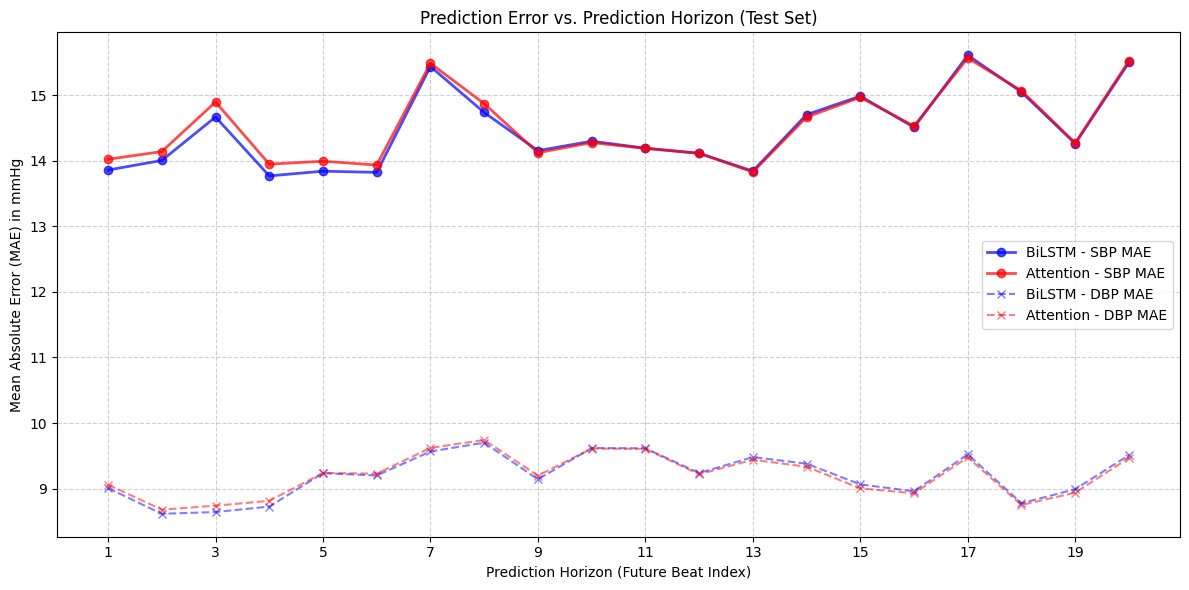

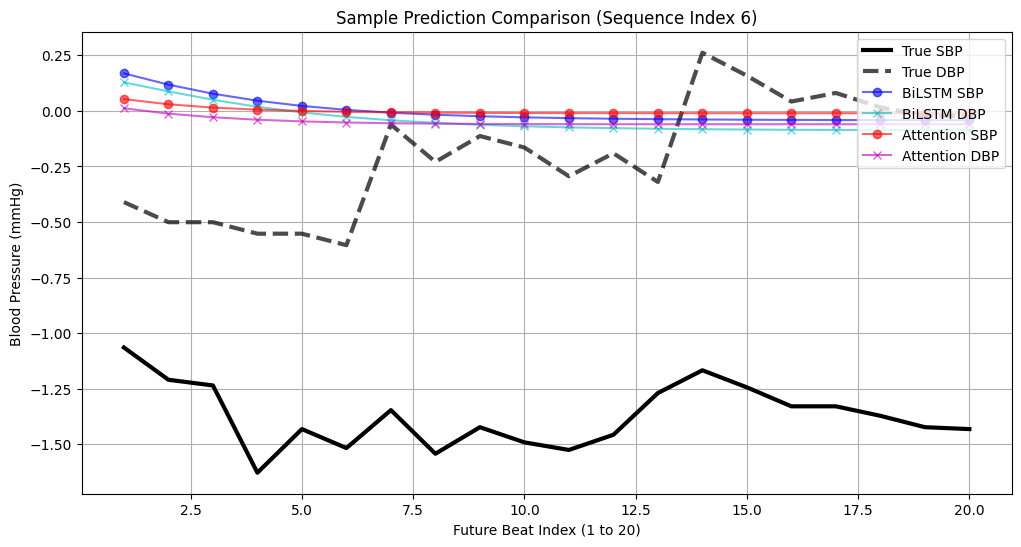

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import torch

# --- 1. Comparative Results Table (Task 10) ---
print("="*50)
print("             MODEL COMPARISON (Test Set)")
print("="*50)

comparison_data = {
    'Model': ['BiLSTM', 'Attention-Seq2Seq'],
    'Overall MAE (mmHg)': [results['BiLSTM']['MAE'], results['Attention']['MAE']],
    'SBP MAE (mmHg)': [results['BiLSTM']['MAE_SBP'], results['Attention']['MAE_SBP']],
    'DBP MAE (mmHg)': [results['BiLSTM']['MAE_DBP'], results['Attention']['MAE_DBP']],
    'RMSE (mmHg)': [results['BiLSTM']['RMSE'], results['Attention']['RMSE']],
    'R² Score': [results['BiLSTM']['R2'], results['Attention']['R2']]
}

df_comparison = pd.DataFrame(comparison_data).set_index('Model').round(3)
# Print the results in Markdown table format
print(df_comparison.to_markdown())
print("="*50)

# --- 2. Error vs. Prediction Horizon Plot (Task 11) ---

# Calculate Horizon Error for both models
mae_horizon_bilstm, _ = calculate_horizon_error(results['BiLSTM']['targets'], results['BiLSTM']['preds'])
mae_horizon_attn, _ = calculate_horizon_error(results['Attention']['targets'], results['Attention']['preds'])

horizon_index = np.arange(1, M_OUT + 1) # Beats 1 to 20

plt.figure(figsize=(12, 6))

# Plot SBP Horizon Error
plt.plot(horizon_index, mae_horizon_bilstm[:, 0], 'b-o', label='BiLSTM - SBP MAE', linewidth=2, alpha=0.7)
plt.plot(horizon_index, mae_horizon_attn[:, 0], 'r-o', label='Attention - SBP MAE', linewidth=2, alpha=0.7)

# Plot DBP Horizon Error
plt.plot(horizon_index, mae_horizon_bilstm[:, 1], 'b--x', label='BiLSTM - DBP MAE', linewidth=1.5, alpha=0.5)
plt.plot(horizon_index, mae_horizon_attn[:, 1], 'r--x', label='Attention - DBP MAE', linewidth=1.5, alpha=0.5)

plt.title('Prediction Error vs. Prediction Horizon (Test Set)')
plt.xlabel('Prediction Horizon (Future Beat Index)')
plt.ylabel('Mean Absolute Error (MAE) in mmHg')
plt.xticks(horizon_index[::2])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'horizon_error_comparison.png')
plt.show()


# --- 3. Sample Prediction Plot (Task 11 - Single Example) ---
# Assuming test_dataset is available from previous cells
sample_idx = random.randint(0, len(test_dataset) - 1)
_, y_true = test_dataset[sample_idx]
y_true = y_true.numpy()

# Get predictions from both models (ensure both models are loaded with best weights from disk)
model_bilstm.load_state_dict(torch.load(OUTPUT_DIR / 'best_model_bilstm.pth'))
model_attn.load_state_dict(torch.load(OUTPUT_DIR / 'best_model_attention.pth'))

model_bilstm.eval()
X_sample, _ = test_dataset[sample_idx]
X_sample = X_sample.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    y_pred_bilstm = model_bilstm(X_sample).squeeze(0).cpu().numpy()

model_attn.eval()
with torch.no_grad():
    y_pred_output_attn = model_attn(X_sample)
    y_pred_attn = y_pred_output_attn[0].squeeze(0).cpu().numpy()


plt.figure(figsize=(12, 6))

plt.plot(horizon_index, y_true[:, 0], 'k-', label='True SBP', linewidth=3)
plt.plot(horizon_index, y_true[:, 1], 'k--', label='True DBP', linewidth=3, alpha=0.7)

plt.plot(horizon_index, y_pred_bilstm[:, 0], 'b-o', label='BiLSTM SBP', alpha=0.6)
plt.plot(horizon_index, y_pred_bilstm[:, 1], 'c-x', label='BiLSTM DBP', alpha=0.6)

plt.plot(horizon_index, y_pred_attn[:, 0], 'r-o', label='Attention SBP', alpha=0.6)
plt.plot(horizon_index, y_pred_attn[:, 1], 'm-x', label='Attention DBP', alpha=0.6)

plt.title(f'Sample Prediction Comparison (Sequence Index {sample_idx})')
plt.xlabel(f'Future Beat Index (1 to {M_OUT})')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig(OUTPUT_DIR / f'sample_prediction_comparison_{sample_idx}.png')
plt.show()


== BEFORE inverse transform ==

--- DIAGNOSTIC: BiLSTM_Seq2Seq sample 10 ---
Shapes: y_true: (20, 2)  y_pred: (20, 2)
y_true stats — min, mean, max (SBP,DBP): 0.5396266 1.1577642 1.6906415 / -0.06728506 0.9041974 1.2237216
y_pred stats — min, mean, max (SBP,DBP): -0.05783326 -0.049091868 -0.043115944 / -0.11599836 -0.09585495 -0.08868866
SBP MAE: 1.207 | DBP MAE: 1.000
Beat-wise SBP error: [1.1003132 1.1041437 1.192838  1.066392  0.6824456 1.6189572 1.531833
 1.188809  1.2722008 1.2279313 1.3970803 1.2254497 1.2672039 1.7354574
 1.3938979 1.222986  1.1374328 0.5830226 0.966533  1.2221953]
Beat-wise DBP error: [0.8233173  0.8806506  0.6832045  0.93919426 0.03381597 0.5486543
 1.1280475  1.1265225  1.1896452  1.1883655  1.1872604  1.2508849
 1.2501279  1.3140712  1.3135917  1.184117   1.1192775  0.731754
 1.0543368  1.0542089 ]


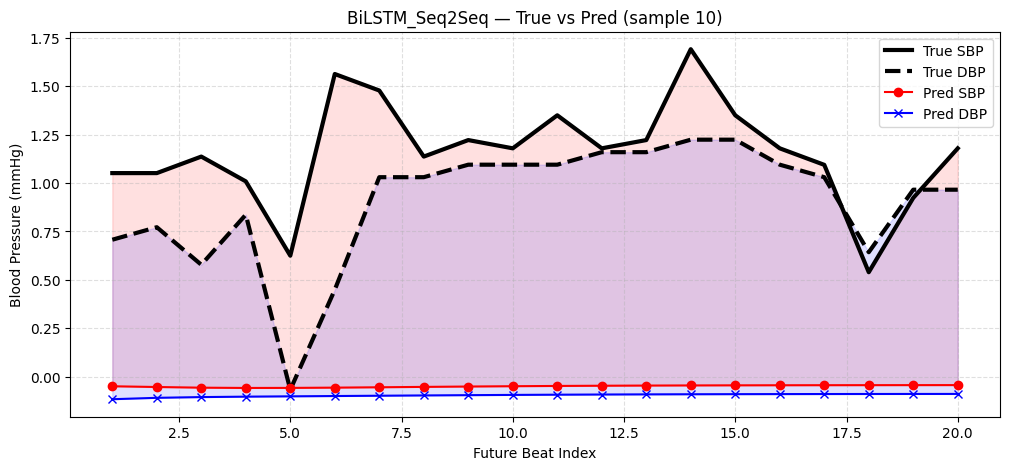

Inferred train stats: {'mean': 2.7743252e-09, 'std': 1.0, 'min': -2.7428975, 'max': 4.6448894}

Applying inverse transform using method: minmax

== AFTER inverse transform ==

--- DIAGNOSTIC: BiLSTM_Seq2Seq sample 10 ---
Shapes: y_true: (20, 2)  y_pred: (20, 2)
y_true stats — min, mean, max (SBP,DBP): 1.2437489 5.810418 9.747202 / -3.2399852 3.93712 6.2976966
y_pred stats — min, mean, max (SBP,DBP): -3.1701574 -3.1055777 -3.061429 / -3.5998688 -3.4510536 -3.3981104
SBP MAE: 8.916 | DBP MAE: 7.388
Beat-wise SBP error: [ 8.128879   8.157178   8.812432   7.8782763  5.0417624 11.960511
 11.316857   8.782668   9.398748   9.071694  10.321331   9.053361
  9.361832  12.82119   10.297821   9.03516    8.403111   4.307246
  7.14054    9.029318 ]
Beat-wise DBP error: [6.0824924  6.5060587  5.047369   6.938567   0.24982524 4.053341
 8.333775   8.322508   8.788845   8.77939    8.771227   9.241271
 9.235679   9.708077   9.7045355  8.748004   8.268984   5.4060426
 7.789216   7.788271  ]


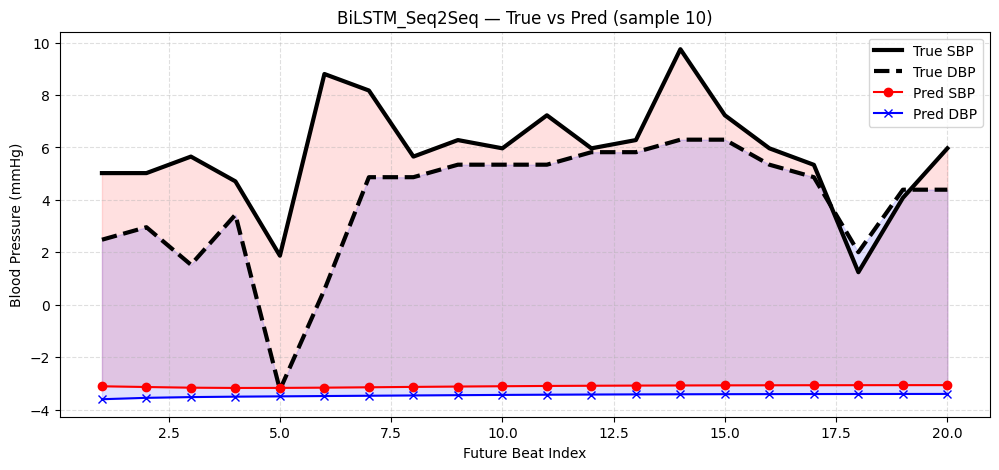


Overall MAE after inverse transform — SBP: 8.916 mmHg | DBP: 7.388 mmHg


<Figure size 640x480 with 0 Axes>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import torch

# -------------------------
# SETTINGS - edit if known
# -------------------------
# If you normalized with z-score, set scaling='zscore' and define bp_mean, bp_std (shape (2,) or scalar).
# If you normalized with min-max, set scaling='minmax' and define bp_min, bp_max.
# If you don't know, leave scaling='auto' and the code will try to infer train stats.
scaling = 'auto'   # 'zscore', 'minmax', or 'auto'

# If you used known stats during preprocessing, set them here (optional)
# Example: bp_mean = np.array([100.0, 70.0]); bp_std = np.array([12.0, 8.0])
# Example: bp_min = np.array([40.0, 30.0]); bp_max = np.array([180.0, 120.0])
bp_mean = globals().get('bp_mean', None)
bp_std  = globals().get('bp_std',  None)
bp_min  = globals().get('bp_min',  None)
bp_max  = globals().get('bp_max',  None)

# -------------------------
# Helper functions
# -------------------------
def infer_train_stats_from_dataset(dataset):
    """If you don't have stored scalers, compute mean/std or min/max from train dataset."""
    try:
        Ys = []
        for i in range(len(dataset)):
            _, y = dataset[i]
            Ys.append(y.numpy())
        Ys = np.concatenate(Ys, axis=0)  # (N_samples, M_out, 2)
        mean = Ys.mean(axis=(0,1))
        std  = Ys.std(axis=(0,1))
        mn   = Ys.min(axis=(0,1))
        mx   = Ys.max(axis=(0,1))
        return {'mean':mean, 'std':std, 'min':mn, 'max':mx}
    except Exception as e:
        print("Could not infer train stats from dataset:", e)
        return None

def inverse_transform(y, scaling_method, stats):
    """
    y: numpy array shape (M_out, 2) or (N, M_out, 2)
    stats: dict with mean,std or min,max
    """
    if scaling_method == 'zscore':
        return y * stats['std'] + stats['mean']
    elif scaling_method == 'minmax':
        return y * (stats['max'] - stats['min']) + stats['min']
    else:
        raise ValueError("Unknown scaling method")

def single_diagnostic_plot(y_true, y_pred, idx, model_name):
    horizon = np.arange(1, y_true.shape[0]+1)
    sbp_err = np.abs(y_true[:,0] - y_pred[:,0])
    dbp_err = np.abs(y_true[:,1] - y_pred[:,1])
    print("\n--- DIAGNOSTIC: {} sample {} ---".format(model_name, idx))
    print("Shapes: y_true:", y_true.shape, " y_pred:", y_pred.shape)
    print("y_true stats — min, mean, max (SBP,DBP):", np.min(y_true[:,0]), np.mean(y_true[:,0]), np.max(y_true[:,0]),
          "/", np.min(y_true[:,1]), np.mean(y_true[:,1]), np.max(y_true[:,1]))
    print("y_pred stats — min, mean, max (SBP,DBP):", np.min(y_pred[:,0]), np.mean(y_pred[:,0]), np.max(y_pred[:,0]),
          "/", np.min(y_pred[:,1]), np.mean(y_pred[:,1]), np.max(y_pred[:,1]))
    print("SBP MAE: {:.3f} | DBP MAE: {:.3f}".format(sbp_err.mean(), dbp_err.mean()))
    print("Beat-wise SBP error:", sbp_err)
    print("Beat-wise DBP error:", dbp_err)

    plt.figure(figsize=(12,5))
    plt.plot(horizon, y_true[:,0], 'k-', linewidth=3, label='True SBP')
    plt.plot(horizon, y_true[:,1], 'k--', linewidth=3, label='True DBP')
    plt.plot(horizon, y_pred[:,0], 'r-o', label='Pred SBP')
    plt.plot(horizon, y_pred[:,1], 'b-x', label='Pred DBP')
    plt.fill_between(horizon, y_true[:,0], y_pred[:,0], color='red', alpha=0.12)
    plt.fill_between(horizon, y_true[:,1], y_pred[:,1], color='blue', alpha=0.12)
    plt.title(f"{model_name} — True vs Pred (sample {idx})")
    plt.xlabel('Future Beat Index')
    plt.ylabel('Blood Pressure (mmHg)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()

# -------------------------
# 1) Load a sample and predictions (existing code you already used)
# -------------------------
sample_index = 10   # adjust as needed
# Make sure models are loaded and on device
model_bilstm.eval()
model_attn.eval()

# Obtain true and predicted (use whichever model you want to debug)
# Replace below lines with the model you are inspecting: model_bilstm or model_attn
model = model_bilstm   # change to model_attn to inspect attention
dataset = test_dataset

# Get X and y_true
X_sample, y_true = dataset[sample_index]
y_true_np = y_true.numpy()            # likely normalized or maybe mmHg already

# Get model output
with torch.no_grad():
    X_in = X_sample.unsqueeze(0).to(DEVICE)
    out = model(X_in)
    if isinstance(out, tuple):
        y_pred_tensor = out[0]
    else:
        y_pred_tensor = out
    y_pred_np = y_pred_tensor.squeeze(0).cpu().numpy()

# Diagnostic before inverse transform
print("\n== BEFORE inverse transform ==")
single_diagnostic_plot(y_true_np, y_pred_np, sample_index, model.__class__.__name__)

# -------------------------
# 2) Decide scaling stats
# -------------------------
resolved = False
stats = {}

if scaling == 'zscore' and (bp_mean is not None and bp_std is not None):
    stats['mean'] = np.array(bp_mean)
    stats['std']  = np.array(bp_std)
    method = 'zscore'
    resolved = True
elif scaling == 'minmax' and (bp_min is not None and bp_max is not None):
    stats['min'] = np.array(bp_min)
    stats['max'] = np.array(bp_max)
    method = 'minmax'
    resolved = True
elif scaling == 'auto':
    # Try to infer training stats from available train dataset or loader
    inferred = None
    try:
        inferred = infer_train_stats_from_dataset(train_dataset)  # if you have train_dataset
    except Exception:
        inferred = None
    if inferred is None:
        try:
            # If you have train_loader, aggregate quickly (be careful with memory)
            Ys = []
            for Xb, yb in train_loader:
                Ys.append(yb.numpy())
            Ys = np.concatenate(Ys, axis=0)
            inferred = {'mean': Ys.mean(axis=(0,1)), 'std': Ys.std(axis=(0,1)),
                        'min': Ys.min(axis=(0,1)), 'max': Ys.max(axis=(0,1))}
        except Exception:
            inferred = None

    if inferred is not None:
        # Heuristic: if y_pred mean magnitude is << y_true mean and y_true mean is > ~2,
        # we likely used z-score. We'll choose zscore first.
        print("Inferred train stats:", inferred)
        stats = inferred
        # choose method heuristically
        if abs(np.mean(y_pred_np)) < 3 and np.mean(y_true_np) > 5:
            method = 'zscore'
        else:
            # fallback to minmax if that makes more sense
            method = 'minmax' if (inferred['max'] - inferred['min']).mean() > 1e-3 else 'zscore'
        resolved = True

if not resolved:
    print("\nCould not auto-resolve normalization stats. If you used z-score or min-max during training,\n"
          "please set 'scaling' to 'zscore' or 'minmax' and provide bp_mean/bp_std or bp_min/bp_max.")
    # still proceed to try plotting raw values for comparison
    method = None

# -------------------------
# 3) If we resolved a method, inverse transform and re-diagnostic
# -------------------------
if resolved and method is not None:
    print(f"\nApplying inverse transform using method: {method}")
    if method == 'zscore':
        inv_y_true = inverse_transform(y_true_np, 'zscore', stats)
        inv_y_pred = inverse_transform(y_pred_np, 'zscore', stats)
    else:
        inv_y_true = inverse_transform(y_true_np, 'minmax', stats)
        inv_y_pred = inverse_transform(y_pred_np, 'minmax', stats)

    # Final diagnostics after inverse transform
    print("\n== AFTER inverse transform ==")
    single_diagnostic_plot(inv_y_true, inv_y_pred, sample_index, model.__class__.__name__)

    # Print overall MAE numeric
    mae_sbp = mean_absolute_error(inv_y_true[:,0], inv_y_pred[:,0])
    mae_dbp = mean_absolute_error(inv_y_true[:,1], inv_y_pred[:,1])
    print(f"\nOverall MAE after inverse transform — SBP: {mae_sbp:.3f} mmHg | DBP: {mae_dbp:.3f} mmHg")

    # Save the figure (optional)
    plt.savefig(OUTPUT_DIR / f'diagnostic_{model.__class__.__name__}_sample{sample_index}.png', dpi=150)
else:
    print("\nNo inverse transform applied. Inspect raw diagnostics above.")
